<h1> Geometric Operations and Other Mathematical Tools</h1>


Estimated time needed: **40** minutes


<h2>Objectives</h2>


In the first part of the lab, you will apply geometric transformations to an image. This allows you to perform different operations like reshape translation, i.e. to shift, reshape and rotate the image. In the second part of the lab, you will learn how to apply some basic array and matrix operations to the image. 


<ul>
    <li><a href='#PT'> Geometric Operations  </a>
        <ul>
            <li>Scaling</li>
            <li>Translation</li>
            <li>Rotation</li>   
          </ul>
        <li><a href='#PT'>  Mathematical Operations   </a>
        <ul>
            <li>Array Operations  </li>
            <li>Matix Operations n</li> 
          </ul>


</ul>


----


Download the image for the lab:


In [2]:
!curl -L "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png" -o lenna.png
!curl -L "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png" -o baboon.png
!curl -L "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png" -o barbara.png


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
 24  462k   24  111k    0     0  45559      0  0:00:10  0:00:02  0:00:08 45640
 85  462k   85  397k    0     0   110k      0  0:00:04  0:00:03  0:00:01  110k
100  462k  100  462k    0     0   118k      0  0:00:03  0:00:03 --:--:--  118k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:-

We will be using the following imported functions in this lab:


In [ ]:
import matplotlib.pyplot as plt #Thư viện vẽ đồ thị
from PIL import Image #Thư viện xử lý ảnh
import numpy as np #Thư viện toán học xử lý mảng

First, let's define a helper function to plot two images side-by-side. You will not need to understand this code this moment, but this function will be used repeatedly in this tutorial to showcase the results. 


In [ ]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    # Ảnh gốc
    plt.imshow(image_1,cmap="gray")
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    # Ảnh đã xử lý
    plt.imshow(image_2,cmap="gray")
    plt.title(title_2)
    plt.show()

#  Geometric Transformations


 Geometric transformations allow you to perform different operations like translation, i.e. to shift, reshape and rotate the image.


We can resize an image using the method  <code>resize()</code> of <code>PIL</code> images, which takes the resized image's <code>width</code> and <code>height</code> as paramters. 

Consider the following image:


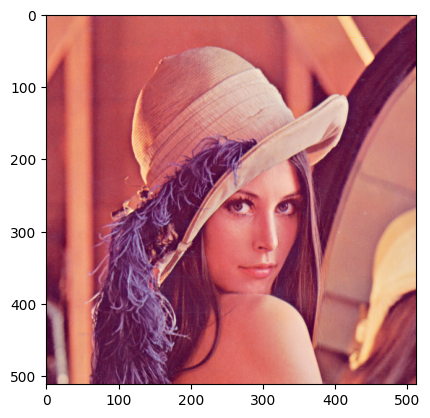

In [5]:
image = Image.open("lenna.png")
plt.imshow(image)
plt.show()

We can scale the horizontal axis by two and leave the vertical axis as is:


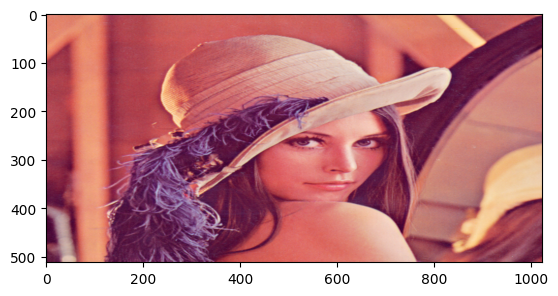

In [ ]:
width, height = image.size # Lấy kích thước ảnh
new_width = 2 * width # Tăng gấp đôi chiều rộng
new_hight = height # Chiều cao không đổi
new_image = image.resize((new_width, new_hight)) #resize ảnh theo kích thước mới
plt.imshow(new_image)
plt.show()

In the same manner, we can scale the vertical axis by two:


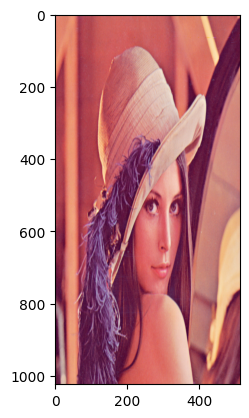

In [ ]:
new_width = width # Chiều rộng không đổi
new_hight = 2 * height # Tăng gấp đôi chiều cao
new_image = image.resize((new_width, new_hight))
plt.imshow(new_image)
plt.show()

We can double both the width and the height of the image:


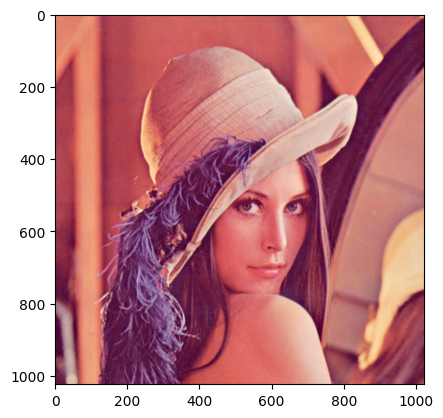

In [ ]:
new_width = 2 * width # Tăng gấp đôi chiều rộng
new_hight = 2 * height # Tăng gấp đôi chiều cao
new_image = image.resize((new_width, new_hight))
plt.imshow(new_image)
plt.show()

We can also shrink the image's width and height both by 1/2:


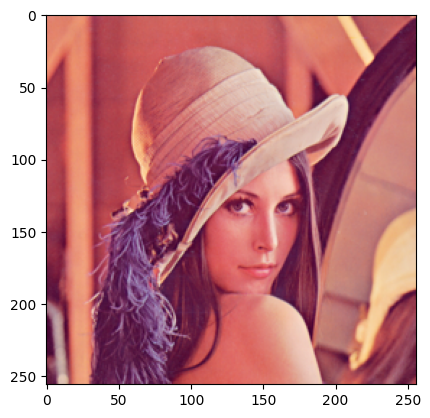

In [ ]:
new_width = width // 2 # Giảm một nửa chiều rộng
new_hight = height // 2 # Giảm một nửa chiều cao

new_image = image.resize((new_width, new_hight))
plt.imshow(new_image)
plt.show()

## Rotation 


We can rotate an image by angle $\theta$, using the method `rotate`.


We can rotate our toy image by 45 degrees:


In [ ]:
theta = 45 #xoay 45 độ
new_image = image.rotate(theta)

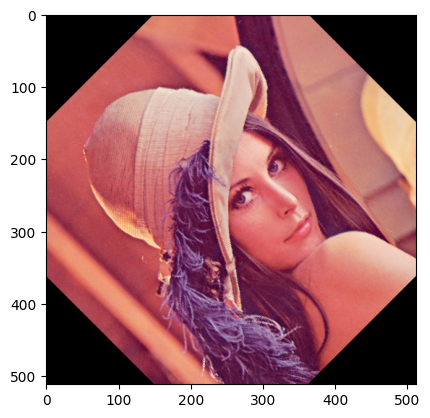

In [11]:
plt.imshow(new_image)
plt.show()

# Mathematical Operations 


## Array Operations 


We can perform array operations on an image; Using Python broadcasting, we can add a constant to each pixel's intensity value. 

Before doing that, we must first we convert the PIL image to a numpy array.


In [12]:
image = np.array(image)

We can then add the constant to the image array:


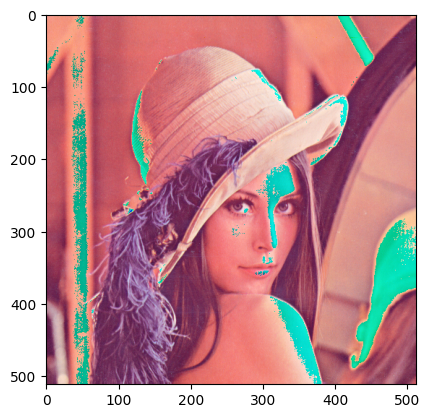

In [ ]:
new_image = image + 20 #tăng giá trị pixel lên 20 
plt.imshow(new_image)
plt.show()

We can also multiply every pixel's intensity value by a constant value.


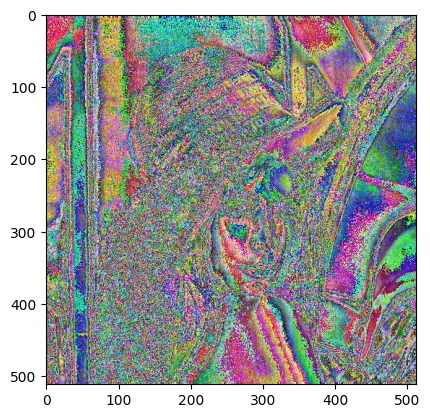

In [ ]:
new_image = 10 * image #tăng giá trị pixel lên 10 lần
plt.imshow(new_image)
plt.show()

We can add the elements of two arrays of equal shape. In this example, we generate an array of random noises with the same shape and data type as our image.


In [15]:
# Thêm nhiễu Gaussian vào ảnh với mean = 0, std = 20 cho ảnh màu (3 kênh RGB)
Noise = np.random.normal(0, 20, (height, width, 3)).astype(np.uint8)
# kiểm tra kích thước của mảng
Noise.shape

(512, 512, 3)

We add the generated noise to the image and plot the result. We see the values that have corrupted the image:


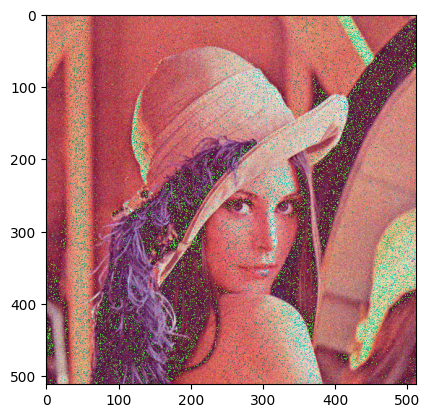

In [ ]:
new_image = image + Noise #cộng nhiễu vào ảnh gốc

plt.imshow(new_image)
plt.show()

At the same time, we can multiply the elements of two arrays of equal shape. We can multiply the random image and the Lenna image and plot the result. 


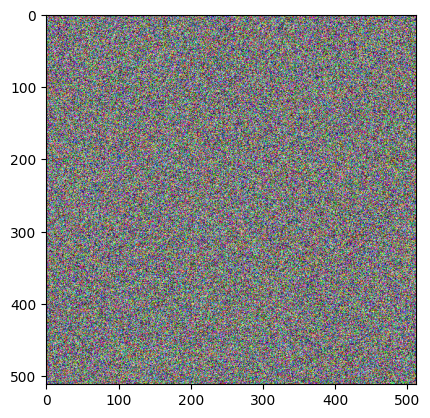

In [ ]:
new_image = image*Noise #nhân nhiễu vào ảnh gốc

plt.imshow(new_image)
plt.show()

## Matrix Operations 


Grayscale images are matrices. Consider the following grayscale image:


In [ ]:
im_gray = Image.open("barbara.png") #Mở ảnh bằng PIL

Even though the image is gray, it has three channels; we can convert it to a one-channel image.


In [ ]:
from PIL import ImageOps #Thư viện xử lý ảnh nâng cao

In [ ]:
im_gray = ImageOps.grayscale(im_gray) #Chuyển ảnh sang ảnh xám

We can convert the PIL image to a numpy array:


In [ ]:
im_gray = np.array(im_gray) #chuyển ảnh PIL sang mảng numpy

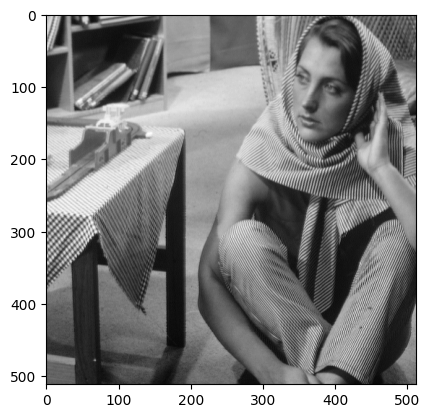

In [22]:
plt.imshow(im_gray,cmap='gray')
plt.show()

We can apply algorithms designed for matrices.  We can use  Singular Value Decomposition, decomposing our image matrix into  a product of three matrices.


In [ ]:
U, s, V = np.linalg.svd(im_gray , full_matrices=True)
# thực hiện svd trên ảnh xám 
# phân rã ma trận ảnh thành 3 ma trận U, s, V

We see <code>s</code> is not rectangular:


In [24]:
s.shape

(512,)

We can convert  <code>s</code> to a diagonal matrix <code>S</code>:


In [ ]:
S = np.zeros((im_gray.shape[0], im_gray.shape[1])) # tạo ma trận S toàn số 0 có cùng kích thước với ảnh xám
S[:image.shape[0], :image.shape[0]] = np.diag(s) # điền các giá trị của vector s vào đường chéo chính của ma trận S

We can plot the matrix U and V:


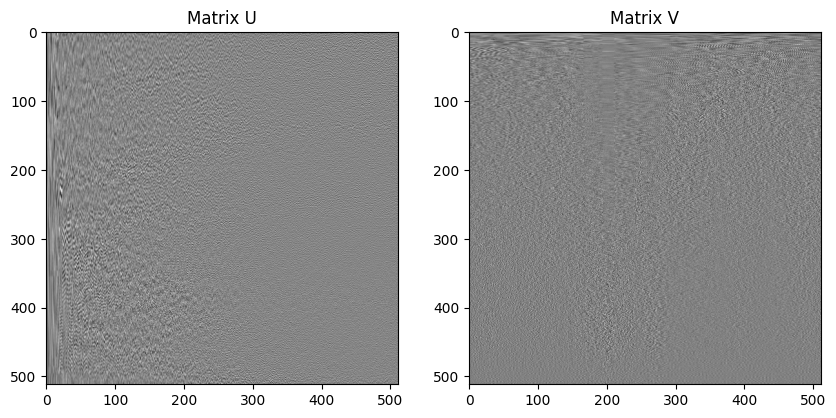

In [ ]:
plot_image(U, V, title_1="Matrix U", title_2="Matrix V") #hiển thị hai ma trân U và V

#### Ma trận `U` 

- Mỗi cột của `U` là 1 pattern theo chiều dọc
- Cho biết ảnh thay đổi từ trên xuống dưới 

#### Ma trận `V`

- Mỗi hàng của `V` là 1 pattern theo chiều ngang
- Cho biết ảnh thay đổi từ trái sang phải

#### Ma trận `S`

- Là ma trận đường chéo
- Các giá trị trên đường chéo là singular values

We see most of the elements in S are zero:


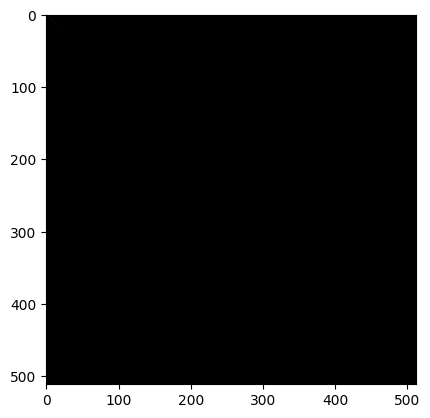

In [27]:
plt.imshow(S, cmap='gray') #hiển thị ma trận S
plt.show()

We can find the matrix product of all the  matrices. First, we can perform matrix multiplication on S and U and assign it to `B` and plot the results: 


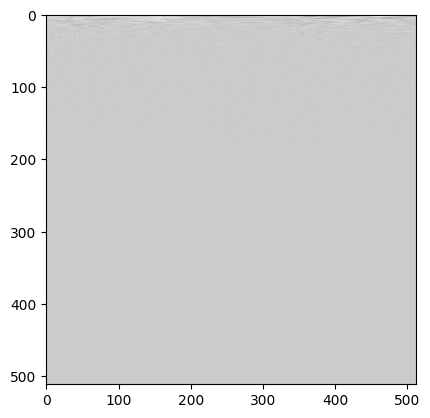

In [28]:
B = S.dot(V) #nhân ma trận S với V
plt.imshow(B,cmap='gray') #hiển thị ma trận B
plt.show()

We can find the matrix product of `U`, `S`, and `B`. We see it's the entire image:


In [ ]:
A = U.dot(B) #nhân ma trận U với B để tái tạo lại ảnh

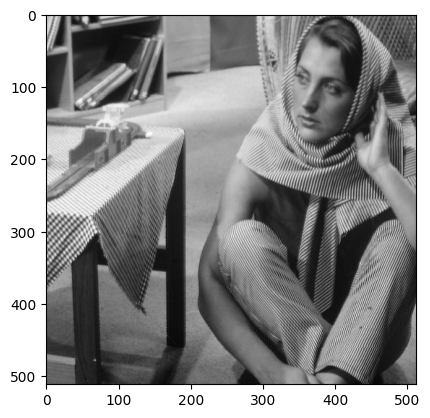

In [30]:
plt.imshow(A,cmap='gray')
plt.show()

It turns out that many elements are redundant. We can eliminate some rows and columns of S and V and approximate the image by finding the product:


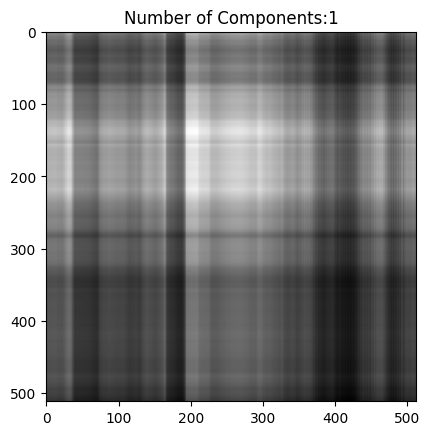

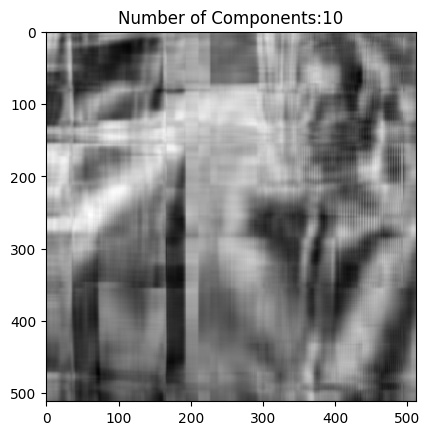

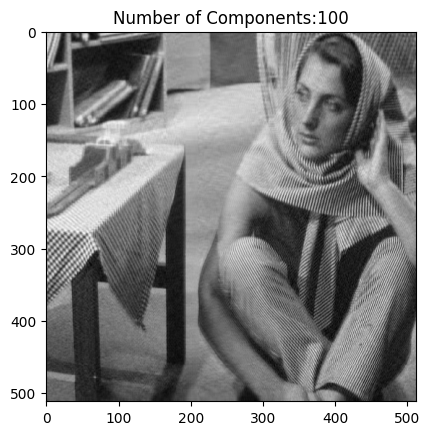

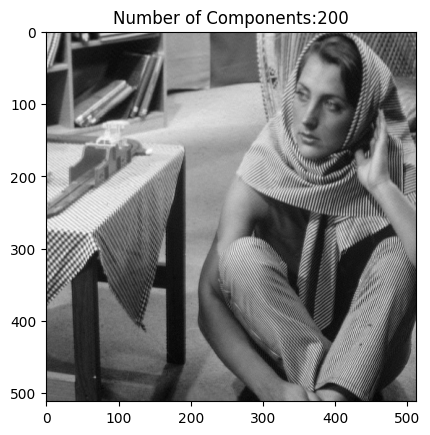

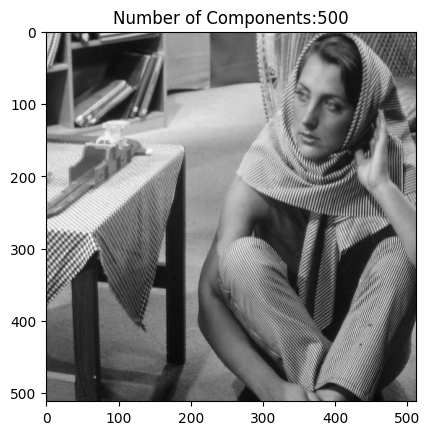

In [32]:
for n_component in [1,10,100,200, 500]: #thay đổi số thành phần chính
    S_new = S[:, :n_component] #lấy n_component cột đầu tiên của ma trận S
    V_new = V[:n_component, :] #lấy n_component hàng đầu tiên của ma trận V
    A = U.dot(S_new.dot(V_new)) #tái tạo ảnh xấp xỉ từ U, S_new và V_new
    plt.imshow(A,cmap='gray')
    plt.title("Number of Components:"+str(n_component))
    plt.show()

#### Giữ lại ít singular values -> ảnh mờ, ít chi tiết
#### Giữ lại nhiều singular values -> ảnh rõ và gần ảnh gốc

We see we only need 100 to 200 Components to represent the image.


# References 


[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<!--<h2>Change Log</h2>-->


<!--<table>
    <tr>
        <th>Date (YYYY-MM-DD)</th>
        <th>Version</th>
        <th>Changed By</th>
        <th>Change Description</th>
    </tr>
    <tr>
        <td>2020-07-20</td>
        <td>0.2</td>
        <td>Azim</td>
        <td>Modified Multiple Areas</td>
    </tr>
    <tr>
        <td>2020-07-17</td>
        <td>0.1</td>
        <td>Azim</td>
        <td>Created Lab Template</td>
    </tr>
</table>
-->


<h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
